In [204]:
!pip install semantic-benchmark rdflib matplotlib


[notice] A new release of pip is available: 25.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [205]:
from semantic_benchmark.rohub import configure_rohub, query_sparql, download_benchmark_resources, extract_uuids_from_subjects

## Configuration

In [206]:
USE_PRODUCTION_ROHUB = True

In [207]:
import re
import requests

software_lookup = {}

def get_software_name(url: str) -> str:
    # Return cached value if we've already looked it up
    if url in software_lookup:
        return software_lookup[url]

    # Extract the software ID
    match = re.search(r"/software/(\d+)", url)
    if not match:
        raise ValueError(f"Invalid zbMATH software URL: {url}")

    software_id = match.group(1)

    # Query the API
    response = requests.get(
        f"https://api.zbmath.org/v1/software/{software_id}",
        headers={"accept": "application/json"},
        timeout=10,
    )
    response.raise_for_status()

    name = response.json()["result"]["name"]

    # Cache the result
    software_lookup[url] = name

    return name

In [208]:
configure_rohub(use_production_rohub=USE_PRODUCTION_ROHUB)

# First query: get run_id, benchmark, software
query = """
PREFIX schema: <https://schema.org/>
PREFIX m4i: <http://w3id.org/nfdi4ing/metadata4ing#>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?run_id ?benchmark_url ?benchmark_repo ?software_url
WHERE {
    ?run_id m4i:investigates ?benchmark_repo .
    ?run_id prov:used ?software_url .
    ?benchmark_url schema:codeRepository ?benchmark_repo.
}
"""

df = query_sparql(query)


# Second query: get named graph for each run_id
run_ids = " ".join([f"<{rid}>" for rid in df["run_id"]])

query_graph = f"""
PREFIX schema: <http://schema.org/>

SELECT ?run_id ?graph
WHERE {{
    VALUES ?run_id {{
        {run_ids}
    }}

    GRAPH ?graph {{
        ?run_id a schema:Dataset .
    }}
}}
"""

df_graph = query_sparql(query_graph)


# Append named graph to the original dataframe
df = df.merge(df_graph, on="run_id", how="left")
df = df.drop(columns=["run_id"])

df["software_name"] = df["software_url"].map(get_software_name)
df = df.drop(columns=["software_url"])

df

,benchmark_url,benchmark_repo,graph,software_name
0,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/f396a01c-8a02-4686-8f85...,OpenFOAM
1,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/fbf9a841-2ec3-47fb-ac05...,DuMuX
2,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/998fa8e9-8aa0-4d58-8bf4...,DuMuX
3,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/53fcb614-25b9-4bf2-a129...,OpenFOAM
4,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/95d6c1f5-d669-47d8-9a52...,KRATOS
5,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/3e35c833-221f-4e49-8a17...,KRATOS
6,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/e717dda0-e4c2-4248-a0fc...,FEniCS
7,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/a4307d64-a9cd-4345-94b1...,FEniCS
8,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/f19ecee4-3efc-442c-9936...,FEniCS
9,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/7d5a3a6c-8083-435e-a0f2...,KRATOS


In [209]:
benchmarks = extract_uuids_from_subjects(df["benchmark_url"].unique().tolist())

In [210]:
ROHUB_USERNAME = "mahdi.jafarkhani@tik.uni-stuttgart.de"
ROHUB_PASSWORD = 'F62VQxcLz83!zdp'

for uuid in benchmarks:
    download_benchmark_resources(uuid, 
                                 username=ROHUB_USERNAME, 
                                 password=ROHUB_PASSWORD, 
                                 semantic_resource_filename=f"{uuid}.json", 
                                 use_production_rohub=USE_PRODUCTION_ROHUB)

Logged successfully as mahdi.jafarkhani@tik.uni-stuttgart.de.
Research Object was successfully loaded with id = b6098239-ec68-41d0-87e6-992b2e4bf406
File was successfully downloaded.
Logged successfully as mahdi.jafarkhani@tik.uni-stuttgart.de.
Research Object was successfully loaded with id = 68b027dd-666b-4b32-a416-952960022c2c
File was successfully downloaded.


## Load the downloaded JSON-LD files and list benchmark parameters and metrics

In [211]:
from pathlib import Path

import pandas as pd
from rdflib import Graph, Namespace
from rdflib.namespace import RDF

# Find the UUID-named semantic files regardless of whether Jupyter was
# started in the repository root or in the notebooks directory.
semantic_files = []
for uuid in benchmarks:
    matches = list(Path.cwd().rglob(f"{uuid}.json"))
    if not matches:
        print(f"Warning: no downloaded JSON-LD file found for {uuid}")
    else:
        semantic_files.append(matches[0])

M4I = Namespace("http://w3id.org/nfdi4ing/metadata4ing#")
kg = Graph()
benchmark_sources = {}
for semantic_file in semantic_files:
    file_graph = Graph().parse(semantic_file, format="json-ld")
    kg += file_graph
    rohub_url = f"https://w3id.org/ro-id/{semantic_file.stem}"
    for benchmark_uri in file_graph.subjects(RDF.type, M4I.Benchmark):
        benchmark_sources[str(benchmark_uri)] = rohub_url

print(f"Loaded {len(semantic_files)} files and {len(kg):,} RDF triples")

query = """
PREFIX m4i:  <http://w3id.org/nfdi4ing/metadata4ing#>
PREFIX bfo:  <http://purl.obolibrary.org/obo/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?benchmark ?benchmarkLabel
       (GROUP_CONCAT(DISTINCT ?parameterLabel; separator=" | " ) AS ?parameters)
       (GROUP_CONCAT(DISTINCT ?metricLabel; separator=" | " ) AS ?metrics)
WHERE {
  ?benchmark a m4i:Benchmark .
  OPTIONAL { ?benchmark rdfs:label ?benchmarkLabel . }
  OPTIONAL {
    ?benchmark m4i:hasParameterSet/bfo:BFO_0000051 ?parameter .
    ?parameter rdfs:label ?parameterLabel .
  }
  OPTIONAL {
    ?benchmark m4i:evaluates ?metric .
    ?metric rdfs:label ?metricLabel .
  }
}
GROUP BY ?benchmark ?benchmarkLabel
ORDER BY LCASE(STR(?benchmarkLabel))
"""

benchmark_summary = pd.DataFrame(
    ([str(value) if value is not None else "" for value in row] for row in kg.query(query)),
    columns=["benchmark_uri", "benchmark", "parameters", "metrics"],
)
benchmark_summary.insert(
    0,
    "benchmark_url",
    benchmark_summary["benchmark_uri"].map(benchmark_sources),
)
benchmark_summary

Loaded 2 files and 662 RDF triples


,benchmark_url,benchmark_uri,benchmark,parameters,metrics
0,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,radius | poissons_ratio | element_size | lengt...,reaction_force_left_boundary_x | reaction_forc...
1,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,rotating cylinders,outer_radius | cells_radial | cells_angular | ...,l2_error_pressure_rel | l2_error_velocity_rel


## Join run metadata with benchmark semantics and query each row

In [212]:
# `df` can contain several runs for one benchmark, while
# `benchmark_summary` contains exactly one row per benchmark.
df_joined = df.merge(
    benchmark_summary,
    on="benchmark_url",
    how="left",
    validate="many_to_one",
)

# Convert the SPARQL GROUP_CONCAT values into convenient Python lists.
for column in ["parameters", "metrics"]:
    df_joined[column] = df_joined[column].fillna("").map(
        lambda value: value.split(" | ") if value else []
    )

df_joined

,benchmark_url,benchmark_repo,graph,software_name,benchmark_uri,benchmark,parameters,metrics
0,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/f396a01c-8a02-4686-8f85...,OpenFOAM,https://github.com/Simulation-Benchmarks/rotat...,rotating cylinders,"[outer_radius, cells_radial, cells_angular, an...","[l2_error_pressure_rel, l2_error_velocity_rel]"
1,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/fbf9a841-2ec3-47fb-ac05...,DuMuX,https://github.com/Simulation-Benchmarks/rotat...,rotating cylinders,"[outer_radius, cells_radial, cells_angular, an...","[l2_error_pressure_rel, l2_error_velocity_rel]"
2,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/998fa8e9-8aa0-4d58-8bf4...,DuMuX,https://github.com/Simulation-Benchmarks/rotat...,rotating cylinders,"[outer_radius, cells_radial, cells_angular, an...","[l2_error_pressure_rel, l2_error_velocity_rel]"
3,https://w3id.org/ro-id/b6098239-ec68-41d0-87e6...,https://github.com/Simulation-Benchmarks/rotat...,https://w3id.org/ro-id/53fcb614-25b9-4bf2-a129...,OpenFOAM,https://github.com/Simulation-Benchmarks/rotat...,rotating cylinders,"[outer_radius, cells_radial, cells_angular, an...","[l2_error_pressure_rel, l2_error_velocity_rel]"
4,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/95d6c1f5-d669-47d8-9a52...,KRATOS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."
5,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/3e35c833-221f-4e49-8a17...,KRATOS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."
6,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/e717dda0-e4c2-4248-a0fc...,FEniCS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."
7,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/a4307d64-a9cd-4345-94b1...,FEniCS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."
8,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/f19ecee4-3efc-442c-9936...,FEniCS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."
9,https://w3id.org/ro-id/68b027dd-666b-4b32-a416...,https://github.com/Simulation-Benchmarks/linea...,https://w3id.org/ro-id/7d5a3a6c-8083-435e-a0f2...,KRATOS,https://github.com/BAMresearch/NFDI4IngModelVa...,linear-elastic plate with hole,"[radius, poissons_ratio, element_size, length,...","[reaction_force_left_boundary_x, reaction_forc..."


In [213]:
from semantic_benchmark.rohub.provenance import build_dynamic_query


def query_rows(frame, build_sparql, query_function=query_sparql):
    """Run a row-specific SPARQL query and combine all returned rows.

    `build_sparql(row)` must return a SPARQL string. The source DataFrame
    index is retained in `_source_row` so results can be joined back.
    """
    results = []
    for source_row, row in frame.iterrows():
        sparql = build_sparql(row)
        if not sparql:
            continue
        try:
            result = query_function(sparql).copy()
        except Exception as error:
            raise RuntimeError(f"SPARQL failed for DataFrame row {source_row}") from error
        result.insert(0, "_source_row", source_row)
        results.append(result)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


def build_row_sparql(row):
    """Build the provenance query for one run/named graph."""
    if pd.isna(row["graph"]) or not row["parameters"] or not row["metrics"]:
        return None

    return build_dynamic_query(
        parameters=row["parameters"],
        metrics=row["metrics"],
        named_graphs=[row["graph"]],
    )


# Inspect one generated query before sending all queries to RoHub.
print(build_row_sparql(df_joined.iloc[0]))

row_query_results = query_rows(df_joined.head(2), build_row_sparql)
row_query_results

PREFIX schema: <http://schema.org/>

    SELECT ?tool_name ?outer_radius ?cells_radial ?cells_angular ?angular_velocity_outer_cylinder ?angular_velocity_inner_cylinder ?mesh_grading ?inner_radius ?l2_error_pressure_rel ?l2_error_velocity_rel
    WHERE {
        VALUES ?graph {
    <https://w3id.org/ro-id/f396a01c-8a02-4686-8f85-226f41fce806/.ro/annotations/322dde1a-b22c-4a36-9aff-1640f1a5796a.ttl>
}

    GRAPH ?graph {
        ?runAction a schema:CreateAction .
?runAction schema:object ?configuration .
?configuration a schema:PropertyValue .
?software a schema:SoftwareApplication .
?software <http://xmlns.com/foaf/0.1/name> ?tool_name .
?configuration schema:exampleOfWork ?param_outer_radius .
    ?param_outer_radius a <https://bioschemas.org/FormalParameter> ;
        <http://xmlns.com/foaf/0.1/name> "outer_radius" ;
        schema:defaultValue ?outer_radius .
?configuration schema:exampleOfWork ?param_cells_radial .
    ?param_cells_radial a <https://bioschemas.org/FormalParameter> ;

,_source_row,tool_name,outer_radius,cells_radial,cells_angular,angular_velocity_outer_cylinder,angular_velocity_inner_cylinder,mesh_grading,inner_radius,l2_error_pressure_rel,l2_error_velocity_rel
0,0,openfoam,2.0,40,160,0,100,1.1,1.0,0.004713744786767224,0.007040127248350563
1,0,openfoam,2.0,20,80,0,100,1.1,1.0,0.006406048621202627,0.013785118361542078
2,0,openfoam,2.0,80,320,0,100,1.1,1.0,0.0027080008063922376,0.0038220241578067657
3,1,dumux,2.0,40,160,0,100,1.1,1.0,0.00500105,0.0276271
4,1,dumux,2.0,20,80,0,100,1.1,1.0,0.0379324,0.133256
5,1,dumux,2.0,80,320,0,100,1.1,1.0,0.00224003,0.00992169


## Group runs and query once per benchmark

In [214]:
# Each value is a DataFrame containing all runs for one benchmark.
benchmark_groups = {
    benchmark_url: group.copy()
    for benchmark_url, group in df_joined.groupby("benchmark_url", sort=True)
}

for benchmark_url, group in benchmark_groups.items():
    print(
        group["benchmark"].iloc[0],
        f"({len(group)} runs)",
        "parameters:", group["parameters"].iloc[0],
        "metrics:", group["metrics"].iloc[0],
    )

linear-elastic plate with hole (11 runs) parameters: ['radius', 'poissons_ratio', 'element_size', 'length', 'cell_type', 'isoparametric_element_degree', 'load', 'youngs_modulus'] metrics: ['reaction_force_left_boundary_x', 'reaction_force_left_boundary_y', 'max_von_mises_stress', 'number_of_dofs', 'l2_error_displacement', 'max_displacement_error', 'displacement_top_right_corner']
rotating cylinders (4 runs) parameters: ['outer_radius', 'cells_radial', 'cells_angular', 'angular_velocity_outer_cylinder', 'angular_velocity_inner_cylinder', 'mesh_grading', 'inner_radius'] metrics: ['l2_error_pressure_rel', 'l2_error_velocity_rel']


In [215]:
def build_group_sparql(parameters, metrics, named_graphs):
    """Build a dynamic query without querying the software name again."""
    sparql = build_dynamic_query(parameters, metrics, named_graphs)
    sparql = sparql.replace("SELECT ?tool_name ", "SELECT ?graph ", 1)

    software_patterns = {
        "?software a schema:SoftwareApplication .",
        f"?software <http://xmlns.com/foaf/0.1/name> ?tool_name .",
    }
    return "\n".join(
        line for line in sparql.splitlines()
        if line.strip() not in software_patterns
    )


def query_benchmark_groups(groups, query_function=query_sparql):
    """Run one dynamic provenance query for each benchmark."""
    results = {}

    for benchmark_url, group in groups.items():
        parameters = group["parameters"].iloc[0]
        metrics = group["metrics"].iloc[0]
        named_graphs = group["graph"].dropna().drop_duplicates().tolist()

        if not parameters or not metrics or not named_graphs:
            print(f"Skipping {benchmark_url}: incomplete semantic metadata")
            continue

        sparql = build_group_sparql(parameters, metrics, named_graphs)
        result = query_function(sparql)

        # Recover the existing software name through the selected graph.
        graph_metadata = group[["graph", "software_name"]].drop_duplicates()
        result = result.merge(
            graph_metadata, on="graph", how="left", validate="many_to_one"
        )
        results[benchmark_url] = result

    return results


# One result DataFrame per benchmark, keyed by benchmark URL.
grouped_query_results = query_benchmark_groups(benchmark_groups)

for benchmark_url, result in grouped_query_results.items():
    print(benchmark_url, result.shape)

https://w3id.org/ro-id/68b027dd-666b-4b32-a416-952960022c2c (104, 17)
https://w3id.org/ro-id/b6098239-ec68-41d0-87e6-992b2e4bf406 (12, 11)


## Plot a parameter against a metric for different tools

In [216]:
import matplotlib.pyplot as plt


def benchmark_plot_options(groups):
    """List the parameter and metric choices for every benchmark."""
    return {
        benchmark_url: {
            "name": group["benchmark"].iloc[0],
            "parameters": group["parameters"].iloc[0],
            "metrics": group["metrics"].iloc[0],
        }
        for benchmark_url, group in groups.items()
    }


plot_options = benchmark_plot_options(benchmark_groups)
plot_options

{'https://w3id.org/ro-id/68b027dd-666b-4b32-a416-952960022c2c': {'name': 'linear-elastic plate with hole',
  'parameters': ['radius',
   'poissons_ratio',
   'element_size',
   'length',
   'cell_type',
   'isoparametric_element_degree',
   'load',
   'youngs_modulus'],
  'metrics': ['reaction_force_left_boundary_x',
   'reaction_force_left_boundary_y',
   'max_von_mises_stress',
   'number_of_dofs',
   'l2_error_displacement',
   'max_displacement_error',
   'displacement_top_right_corner']},
 'https://w3id.org/ro-id/b6098239-ec68-41d0-87e6-992b2e4bf406': {'name': 'rotating cylinders',
  'parameters': ['outer_radius',
   'cells_radial',
   'cells_angular',
   'angular_velocity_outer_cylinder',
   'angular_velocity_inner_cylinder',
   'mesh_grading',
   'inner_radius'],
  'metrics': ['l2_error_pressure_rel', 'l2_error_velocity_rel']}}

In [217]:
def plot_parameter_vs_metric(
    benchmark_url,
    parameter,
    metric,
    *,
    results=grouped_query_results,
    options=plot_options,
    xscale="linear",
    yscale="linear",
    aggregate="mean",
    ax=None,
):
    """Plot one benchmark's parameter/metric relationship by tool.

    Each named graph is treated as a separate run. Repeated observations
    within the same run and parameter value are aggregated using
    `aggregate` (for example, 'mean', 'median', 'min', or 'max').
    """
    if benchmark_url not in results:
        raise KeyError(f"No query results for benchmark: {benchmark_url}")

    choices = options[benchmark_url]
    if parameter not in choices["parameters"]:
        raise ValueError(
            f"Unknown parameter {parameter!r}; choose from {choices['parameters']}"
        )
    if metric not in choices["metrics"]:
        raise ValueError(
            f"Unknown metric {metric!r}; choose from {choices['metrics']}"
        )

    data = results[benchmark_url][["graph", "software_name", parameter, metric]].copy()
    data[parameter] = pd.to_numeric(data[parameter], errors="coerce")
    data[metric] = pd.to_numeric(data[metric], errors="coerce")
    data = data.dropna(subset=["graph", "software_name", parameter, metric])
    if data.empty:
        raise ValueError("The selected parameter and metric contain no scalar numeric data.")

    data = (
        data.groupby(["software_name", "graph", parameter], as_index=False)[metric]
        .agg(aggregate)
        .sort_values(parameter)
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    for (tool, graph), run_data in data.groupby(
        ["software_name", "graph"], sort=True
    ):
        run_id = str(graph).rstrip("/").split("/")[-1][:8]
        ax.plot(
            run_data[parameter],
            run_data[metric],
            marker="o",
            linewidth=1.8,
            label=f"{tool} — run {run_id}",
        )

    ax.set(
        xlabel=parameter,
        ylabel=metric,
        title=f"{choices['name']}: {metric} vs {parameter}",
        xscale=xscale,
        yscale=yscale,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(title="Tool and run")
    ax.figure.tight_layout()
    return ax


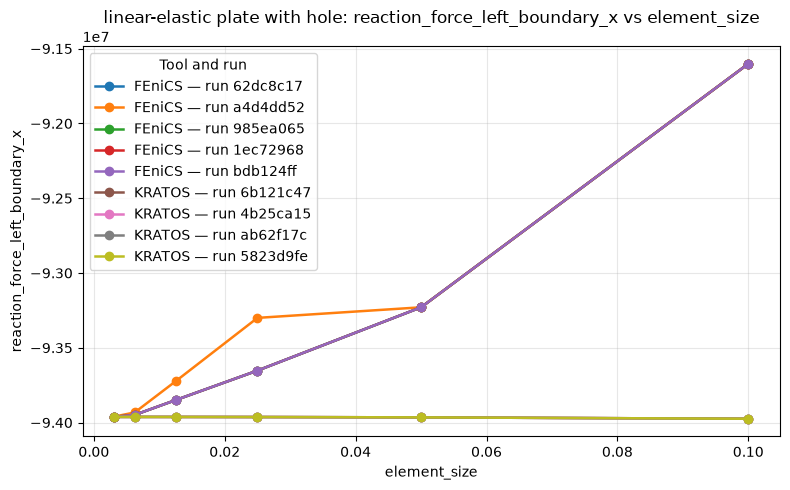

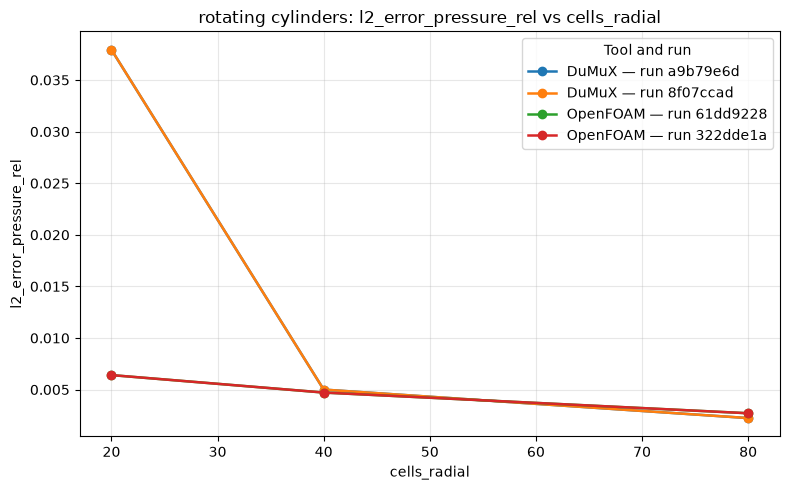

In [218]:
def suggest_plot(benchmark_url, results=grouped_query_results, options=plot_options):
    """Choose the most varied numeric parameter and the first metric."""
    data = results[benchmark_url]
    parameters = options[benchmark_url]["parameters"]
    metrics = options[benchmark_url]["metrics"]
    numeric_parameters = {
        parameter: pd.to_numeric(data[parameter], errors="coerce").nunique()
        for parameter in parameters
        if parameter in data
    }
    if not numeric_parameters or not metrics:
        raise ValueError("No plottable parameter/metric combination is available.")
    return max(numeric_parameters, key=numeric_parameters.get), metrics[0]


# Create one suggested plot for every benchmark. Replace the suggested
# names with any choices shown in `plot_options`.
for benchmark_url in grouped_query_results:
    parameter, metric = suggest_plot(benchmark_url)
    plot_parameter_vs_metric(benchmark_url, parameter, metric)
    plt.show()

# Explicit example:
# plot_parameter_vs_metric(
#     benchmark_url=next(iter(grouped_query_results)),
#     parameter="cells_radial",
#     metric="l2_error_velocity_rel",
#     yscale="log",
# )